## GAM Analysis

In [9]:
import geopandas as gpd
import rasterio
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pygam import LinearGAM, s


# Paths to Clusterdata of each region, elevation, suface velocity, strain rate and flow difference

path_clusters = "C:/Masterarbeit/Daten Masterarbeit/Outputs/Moran_Approach2/SW_1.0kmR.gpkg"
#path_clusters = "C:/Masterarbeit/Daten Masterarbeit/Outputs/Moran_Approach2/CW_1.0kmR.gpkg"
#path_clusters = "C:/Masterarbeit/Daten Masterarbeit/Outputs/Moran_Approach2/NW_1.0kmR.gpkg"
#path_clusters = "C:/Masterarbeit/Daten Masterarbeit/Outputs/Moran_Approach2/NO_1.0kmR.gpkg"
#path_clusters = "C:/Masterarbeit/Daten Masterarbeit/Outputs/Moran_Approach2/NE_1.0kmR.gpkg"
path_diff     = "C:/Masterarbeit/Daten Masterarbeit/Datasets/Greenland/ArcticDEM/deg_difference/deg_difference100_python_Greenland.tif"
path_elev     = "C:/Masterarbeit/Daten Masterarbeit/Datasets/Greenland/ArcticDEM/arcticdem_mosaic_100m_v4.1/arcticdem_mosaic_100m_v4.1_dem.tif"
path_velo     = "C:/Masterarbeit/Daten Masterarbeit/Datasets/Greenland/Ice velocity/ITSLIVE/ITS_LIVE_Ice_Surface_Velocity_CRS.tif"
path_strain   = "C:/Masterarbeit/Daten Masterarbeit/Datasets/Strain rates (Poinar)/primary_principal_strain_rate_1995-2015_yr-1.tif"

# Set CRS of all data to same CRS (EPSG:3414)
def sample_raster(gdf, raster_path, col_name):
    with rasterio.open(raster_path) as src:
        if src.crs is not None:
            if gdf.crs != src.crs:
                gdf = gdf.to_crs(src.crs)
        else:
            print("Warning")
            
        coords = [(g.x, g.y) for g in gdf.geometry]
        
        try:
            sampled_values = [val[0] for val in src.sample(coords)]
            gdf[col_name] = sampled_values
        except Exception as e:
            gdf[col_name] = np.nan
            
    return gdf

# Cluster Data loading
gdf = gpd.read_file(path_clusters)

# extraction of raster values
gdf = sample_raster(gdf, path_diff, 'angle_diff_deg')
gdf = sample_raster(gdf, path_elev, 'elevation')
gdf = sample_raster(gdf, path_velo, 'ice_velocity')
gdf = sample_raster(gdf, path_strain, 'strain_rate')

# relevatn column ice slab thickness
thick_col = 'ice_1km_mean' 

# cleaning of variables
gdf_clean = gdf[
    (gdf['angle_diff_deg'] >= 0) & 
    (gdf[thick_col] > 0) & 
    (gdf['elevation'] > -500) & 
    (gdf['ice_velocity'] >= 0) &
    (gdf['strain_rate'].notna())
].copy()

print(gdf_clean[['ice_1km_mean', 'elevation', 'ice_velocity', 'strain_rate']].head())

   ice_1km_mean    elevation  ice_velocity  strain_rate
0      6.739335  1665.625000     52.879299       -0.002
1      6.732522  1666.210938     52.879299       -0.002
2      6.726500  1666.210938     52.879299       -0.002
3      6.727290  1666.210938     52.879299       -0.002
4      6.723939  1666.210938     52.879299       -0.002


### Bivariate GAM

In [10]:
# ice slab thickness vs. surface water
# addapt x_hydro if not boxcox but log

x_hydro = gdf_clean[['hydro_boxcox']].values
#x_hydro = gdf_clean[['hydro_log_capped']].values
y = gdf_clean['ice_1km_mean'].values

# GAM analysis
gam_surfacewater = LinearGAM(s(0)).gridsearch(x_hydro, y)

# Summary
print(gam_surfacewater.summary())

100% (11 of 11) |########################| Elapsed Time: 0:00:21 Time:  0:00:210:01


LinearGAM                                                                                                 
=============================================== ==========================================================
Distribution:                        NormalDist Effective DoF:                                     19.9214
Link Function:                     IdentityLink Log Likelihood:                               -478263.7023
Number of Samples:                       205273 AIC:                                           956569.2473
                                                AICc:                                          956569.2518
                                                GCV:                                                6.1853
                                                Scale:                                              2.4868
                                                Pseudo R-Squared:                                   0.3229
Feature Function                  Lam

C:\Users\Marco Karrer\AppData\Local\Temp\ipykernel_7936\1112169948.py:12: UserWarning: KNOWN BUG: p-values computed in this summary are likely much smaller than they should be. 
 
Please do not make inferences based on these values! 

Collaborate on a solution, and stay up to date at: 
github.com/dswah/pyGAM/issues/163 

  print(gam_surfacewater.summary())


In [11]:
# ice slab thickness vs. elevation

x_elev = gdf_clean[['elevation']].values
y = gdf_clean['ice_1km_mean'].values

# GAM analysis
gam_elevation = LinearGAM(s(0)).gridsearch(x_elev, y)

# Summary
print(gam_elevation.summary())

100% (11 of 11) |########################| Elapsed Time: 0:00:19 Time:  0:00:190:01


LinearGAM                                                                                                 
=============================================== ==========================================================
Distribution:                        NormalDist Effective DoF:                                     19.9764
Link Function:                     IdentityLink Log Likelihood:                               -506442.6967
Number of Samples:                       205273 AIC:                                           1012927.346
                                                AICc:                                         1012927.3505
                                                GCV:                                                8.1395
                                                Scale:                                              2.8527
                                                Pseudo R-Squared:                                    0.109
Feature Function                  Lam

C:\Users\Marco Karrer\AppData\Local\Temp\ipykernel_7936\2459293447.py:10: UserWarning: KNOWN BUG: p-values computed in this summary are likely much smaller than they should be. 
 
Please do not make inferences based on these values! 

Collaborate on a solution, and stay up to date at: 
github.com/dswah/pyGAM/issues/163 

  print(gam_elevation.summary())


In [12]:
# ice slab thickness vs. alignment

x_deg = gdf_clean[['angle_diff_deg']].values
y = gdf_clean['ice_1km_mean'].values

# GAM analysis
gam_alignment= LinearGAM(s(0)).gridsearch(x_deg, y)

# Summary
print(gam_alignment.summary())

100% (11 of 11) |########################| Elapsed Time: 0:00:21 Time:  0:00:210:01


LinearGAM                                                                                                 
=============================================== ==========================================================
Distribution:                        NormalDist Effective DoF:                                      18.532
Link Function:                     IdentityLink Log Likelihood:                               -517614.3647
Number of Samples:                       205273 AIC:                                          1035267.7934
                                                AICc:                                         1035267.7973
                                                GCV:                                                9.0753
                                                Scale:                                              3.0123
                                                Pseudo R-Squared:                                   0.0065
Feature Function                  Lam

C:\Users\Marco Karrer\AppData\Local\Temp\ipykernel_7936\3985517566.py:10: UserWarning: KNOWN BUG: p-values computed in this summary are likely much smaller than they should be. 
 
Please do not make inferences based on these values! 

Collaborate on a solution, and stay up to date at: 
github.com/dswah/pyGAM/issues/163 

  print(gam_alignment.summary())


In [13]:
# ice slab thickness vs. ice velocity

x_vel = gdf_clean['ice_velocity'].values
y = gdf_clean['ice_1km_mean'].values

# GAM analysis
gam_velocity = LinearGAM(s(0)).gridsearch(x_vel, y)

# Summary
print(gam_velocity.summary())

100% (11 of 11) |########################| Elapsed Time: 0:00:21 Time:  0:00:210:02


LinearGAM                                                                                                 
=============================================== ==========================================================
Distribution:                        NormalDist Effective DoF:                                     19.9322
Link Function:                     IdentityLink Log Likelihood:                               -510849.7695
Number of Samples:                       205273 AIC:                                          1021741.4034
                                                AICc:                                         1021741.4079
                                                GCV:                                                8.4966
                                                Scale:                                              2.9146
                                                Pseudo R-Squared:                                   0.0699
Feature Function                  Lam

C:\Users\Marco Karrer\AppData\Local\Temp\ipykernel_7936\4226683008.py:10: UserWarning: KNOWN BUG: p-values computed in this summary are likely much smaller than they should be. 
 
Please do not make inferences based on these values! 

Collaborate on a solution, and stay up to date at: 
github.com/dswah/pyGAM/issues/163 

  print(gam_velocity.summary())


In [14]:
# ice slab thickness vs. strain rate

x_strain = gdf_clean['strain_rate'].values
y = gdf_clean['ice_1km_mean'].values

# GAM analysis
gam_strainrate = LinearGAM(s(0)).gridsearch(x_strain, y)

# Summary
print(gam_strainrate.summary())

100% (11 of 11) |########################| Elapsed Time: 0:00:20 Time:  0:00:200:01


LinearGAM                                                                                                 
=============================================== ==========================================================
Distribution:                        NormalDist Effective DoF:                                     18.7905
Link Function:                     IdentityLink Log Likelihood:                               -516327.1111
Number of Samples:                       205273 AIC:                                          1032693.8031
                                                AICc:                                         1032693.8071
                                                GCV:                                                8.9622
                                                Scale:                                              2.9934
                                                Pseudo R-Squared:                                   0.0189
Feature Function                  Lam

C:\Users\Marco Karrer\AppData\Local\Temp\ipykernel_7936\1805112931.py:10: UserWarning: KNOWN BUG: p-values computed in this summary are likely much smaller than they should be. 
 
Please do not make inferences based on these values! 

Collaborate on a solution, and stay up to date at: 
github.com/dswah/pyGAM/issues/163 

  print(gam_strainrate.summary())


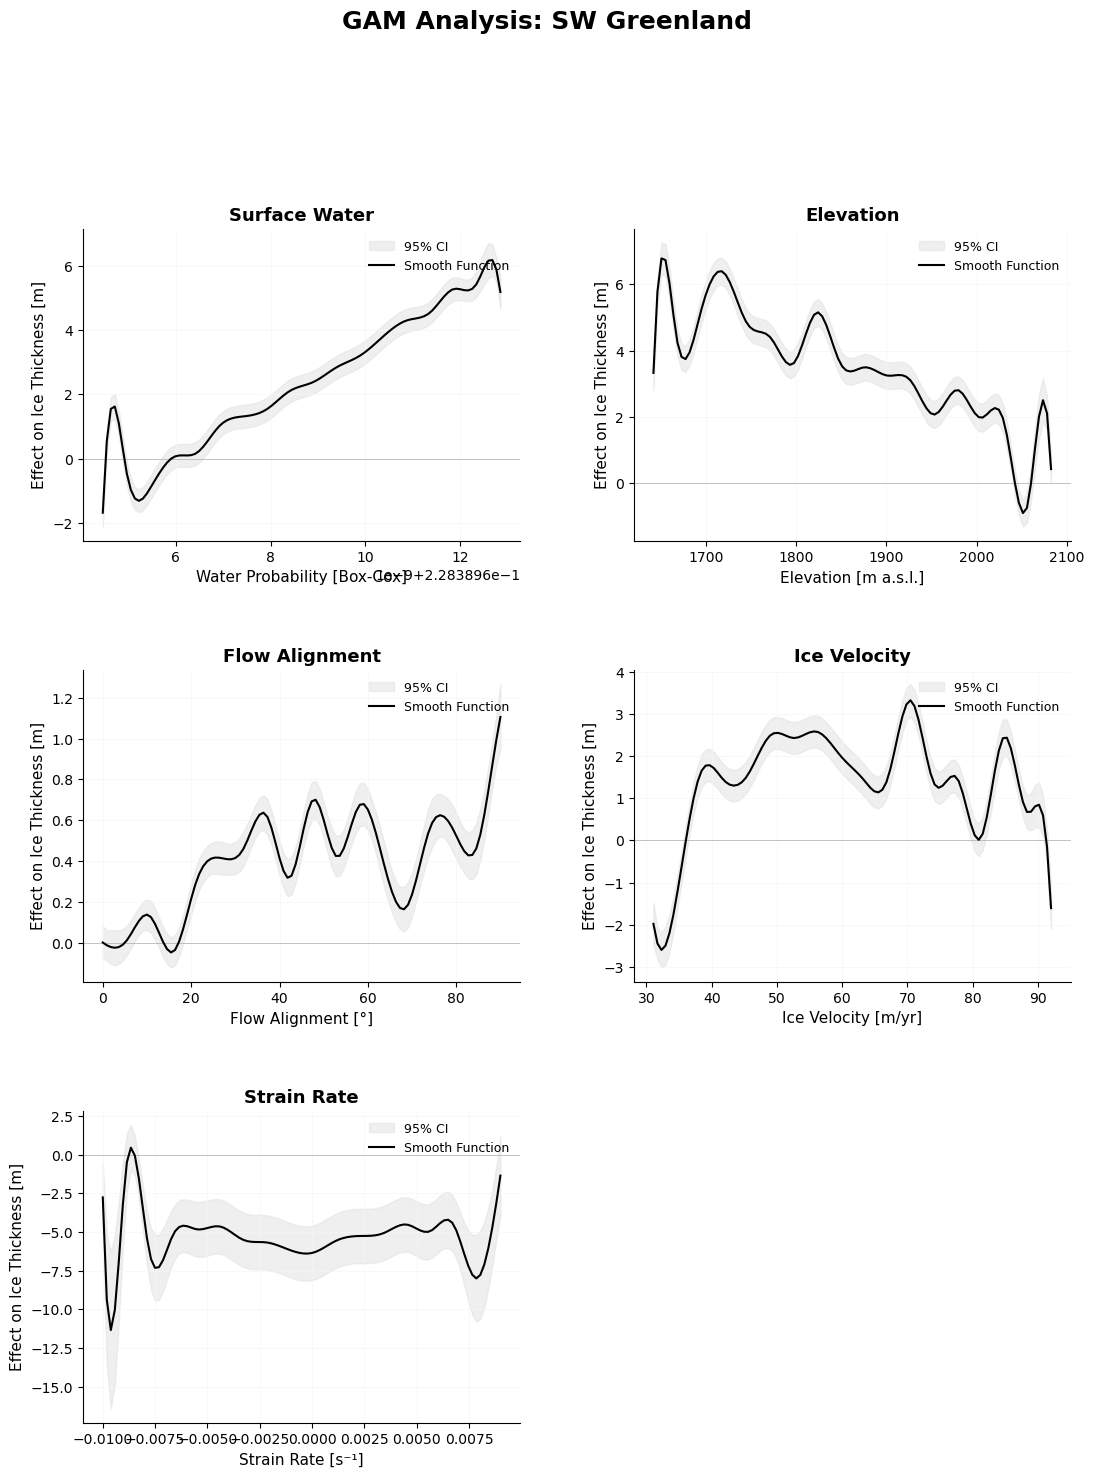

In [15]:
#Visualization of bivariate GAM

# Asigning colours
line_color = '#000000' # black
fill_color = '#E0E0E0' # light grey
grid_color = '#F5F5F5' # transparent grey

models = [gam_surfacewater, gam_elevation, gam_alignment, gam_velocity, gam_strainrate]
names = ['Surface Water', 'Elevation', 'Flow Alignment', 'Ice Velocity', 'Strain Rate']

# x-axis labeling
x_labels = [
    'Water Probability [Box-Cox]', 
    'Elevation [m a.s.l.]', 
    'Flow Alignment [°]', 
    'Ice Velocity [m/yr]', 
    'Strain Rate [s⁻¹]'
]

fig, axs = plt.subplots(3, 2, figsize=(12, 16)) 
axs = axs.flatten() 

fig.suptitle('GAM Analysis: SW Greenland', fontsize=18, fontweight='bold', y=0.98, family='sans-serif')

for i, (model, name, x_label) in enumerate(zip(models, names, x_labels)):
    XX = model.generate_X_grid(term=0)
    pdep, confi = model.partial_dependence(term=0, X=XX, width=0.95)
    
    # 95% confidence intervall
    axs[i].fill_between(XX[:, 0], confi[:, 0], confi[:, 1], color=fill_color, alpha=0.5, label='95% CI')
    
    # smooth function
    axs[i].plot(XX[:, 0], pdep, color=line_color, lw=1.5, label='Smooth Function')
    
    # 0 line
    axs[i].axhline(0, color='black', linestyle='-', lw=0.5, alpha=0.3)
    
    # title and lables
    axs[i].set_title(name, fontsize=13, fontweight='semibold', family='sans-serif')
    axs[i].set_ylabel('Effect on Ice Thickness [m]', fontsize=11, family='sans-serif')
    axs[i].set_xlabel(x_label, fontsize=11, family='sans-serif')
    
    # legend
    axs[i].legend(loc='upper right', fontsize=9, frameon=False)
    
    # design
    axs[i].grid(True, which='major', color=grid_color, linestyle='-', linewidth=0.5)
    axs[i].spines['top'].set_visible(False)
    axs[i].spines['right'].set_visible(False)

# leaving the space for a sixed plot blank
axs[5].axis('off')

plt.tight_layout(rect=[0, 0.03, 1, 0.95], pad=4.5) 

# saveing
#plt.savefig("C:/Masterarbeit/Daten Masterarbeit/Outputs/GAM/SW_GAM_Curve.png", dpi=300, bbox_inches='tight')
plt.show()

### Multivariate GAM

In [16]:
# Multivariate GAM with all four predictors simultaneously

x = gdf_clean[['hydro_log_capped', 'elevation', 'ice_velocity', 'strain_rate']].values
y = gdf_clean['ice_1km_mean'].values

# GAM analysis
gam_all = LinearGAM(s(0) + s(1) + s(2)+ s(3)).gridsearch(x, y)

# Summary
print(gam_all.summary())

100% (11 of 11) |########################| Elapsed Time: 0:01:03 Time:  0:01:030:05


LinearGAM                                                                                                 
=============================================== ==========================================================
Distribution:                        NormalDist Effective DoF:                                     75.7727
Link Function:                     IdentityLink Log Likelihood:                               -462956.9208
Number of Samples:                       205273 AIC:                                           926067.3868
                                                AICc:                                           926067.445
                                                GCV:                                                5.3324
                                                Scale:                                              2.3084
                                                Pseudo R-Squared:                                   0.4167
Feature Function                  Lam

C:\Users\Marco Karrer\AppData\Local\Temp\ipykernel_7936\3708707690.py:10: UserWarning: KNOWN BUG: p-values computed in this summary are likely much smaller than they should be. 
 
Please do not make inferences based on these values! 

Collaborate on a solution, and stay up to date at: 
github.com/dswah/pyGAM/issues/163 

  print(gam_all.summary())


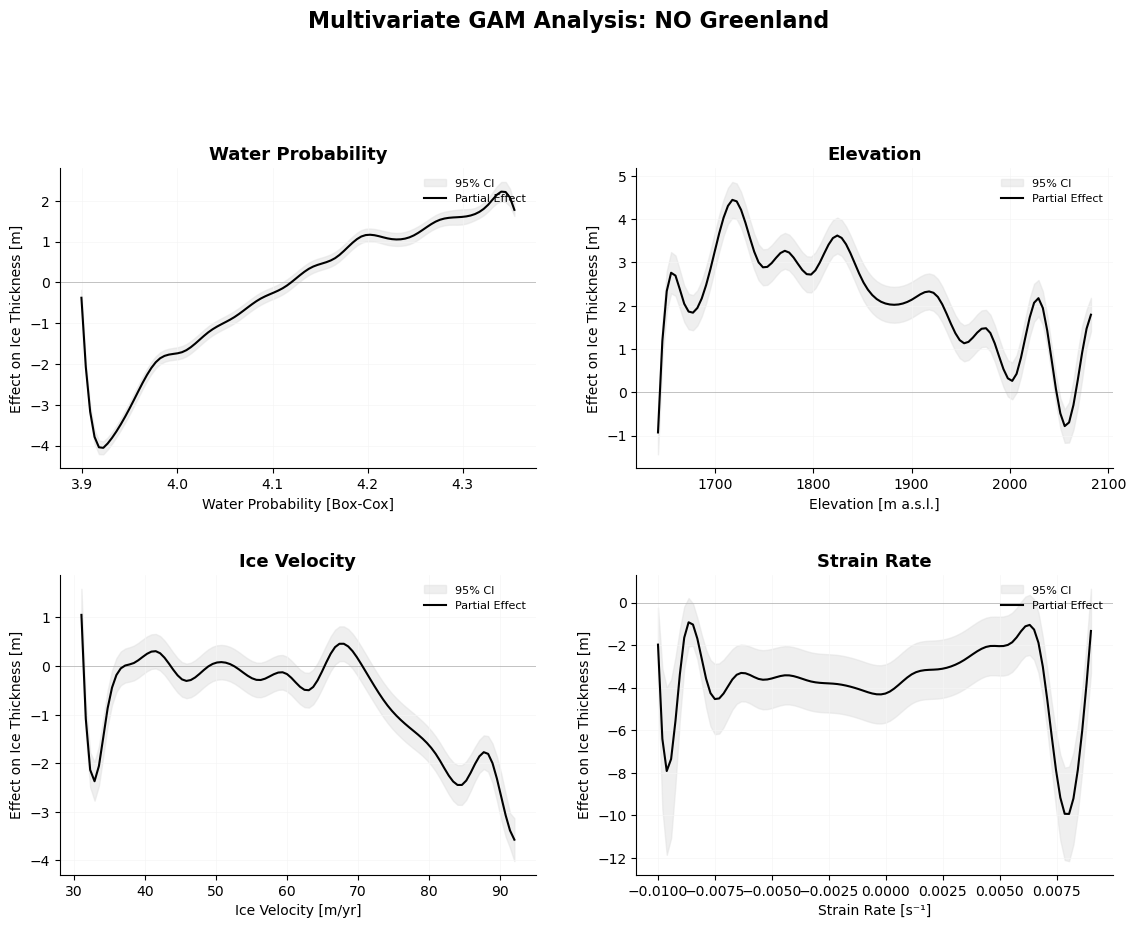

In [17]:
# Visualization of multivariate GAM

# colours
line_color = '#000000'
fill_color = '#E0E0E0'
grid_color = '#F5F5F5'

# indipendet variables
names = ['Water Probability', 'Elevation', 'Ice Velocity', 'Strain Rate']
x_labels = [
    'Water Probability [Box-Cox]', 
    'Elevation [m a.s.l.]', 
    'Ice Velocity [m/yr]', 
    'Strain Rate [s⁻¹]'
]

# plot
fig, axs = plt.subplots(2, 2, figsize=(12, 10))
axs = axs.flatten()

fig.suptitle('Multivariate GAM Analysis: NO Greenland', fontsize=16, fontweight='bold', y=0.98)

for i in range(4):
    # generates grid
    XX = gam_all.generate_X_grid(term=i)
    
    # 95% confidence intervall
    pdep, confi = gam_all.partial_dependence(term=i, X=XX, width=0.95)
    
    # plotting
    axs[i].fill_between(XX[:, i], confi[:, 0], confi[:, 1], color=fill_color, alpha=0.5, label='95% CI')
    axs[i].plot(XX[:, i], pdep, color=line_color, lw=1.5, label='Partial Effect')
    
    # 0 line
    axs[i].axhline(0, color='black', linestyle='-', lw=0.5, alpha=0.3)
    
    # labeling
    axs[i].set_title(names[i], fontsize=13, fontweight='semibold')
    axs[i].set_xlabel(x_labels[i], fontsize=10)
    axs[i].set_ylabel('Effect on Ice Thickness [m]', fontsize=10)
    
    # legend
    axs[i].legend(loc='upper right', fontsize=8, frameon=False)
    
    # design
    axs[i].grid(True, color=grid_color, linestyle='-', linewidth=0.5)
    axs[i].spines['top'].set_visible(False)
    axs[i].spines['right'].set_visible(False)

plt.tight_layout(rect=[0, 0.03, 1, 0.95], pad=3.0)

# saveing
# plt.savefig("C:/Masterarbeit/Outputs/GAM/Multivariate_GAM_NO.pdf", dpi=300)
plt.show()